# India VAHAN Vehicle Registration — Exploratory Analysis

Connects directly to the RDS SQL Server warehouse and works through the core
analysis questions from the project roadmap: national fuel-type trends, EV
adoption by state, per-capita normalization, vehicle category mix shift,
seasonality, charging-infrastructure correlation, and a policy-effect
overlay. Closes with a short illustrative forecast.

**Note on scope:** correlational findings here (GSDP, charging stations,
policy timing) are described as associations, not causal claims — see the
notes under each section.

In [2]:
import os
import urllib.parse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

from sqlalchemy import create_engine, text

# Connection settings — same pattern as load_to_rds.py: read from env vars,
# nothing hardcoded. Set these before launching Jupyter, e.g.:
#   export DB_HOST=<your-rds-endpoint>
#   export DB_NAME=vahan
#   export DB_USER=<your-admin-username>
#   export DB_PASSWORD=<your-password>
DB_HOST = os.environ["DB_HOST"]
DB_NAME = os.environ["DB_NAME"]
DB_USER = os.environ["DB_USER"]
DB_PASSWORD = os.environ["DB_PASSWORD"]

odbc_str = (
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER={DB_HOST},1433;DATABASE={DB_NAME};UID={DB_USER};PWD={DB_PASSWORD};"
    f"Encrypt=yes;TrustServerCertificate=yes;"
)
engine = create_engine("mssql+pyodbc:///?odbc_connect=" + urllib.parse.quote_plus(odbc_str))

# Quick sanity check
with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM fact_registrations")).scalar()
print(f"Connected. fact_registrations row count: {n:,}")

Connected. fact_registrations row count: 179,270


## 1. National registrations by fuel type, over time

Sets the baseline before drilling into EV specifically: how has the overall
fuel-type mix of new registrations shifted since 2017?

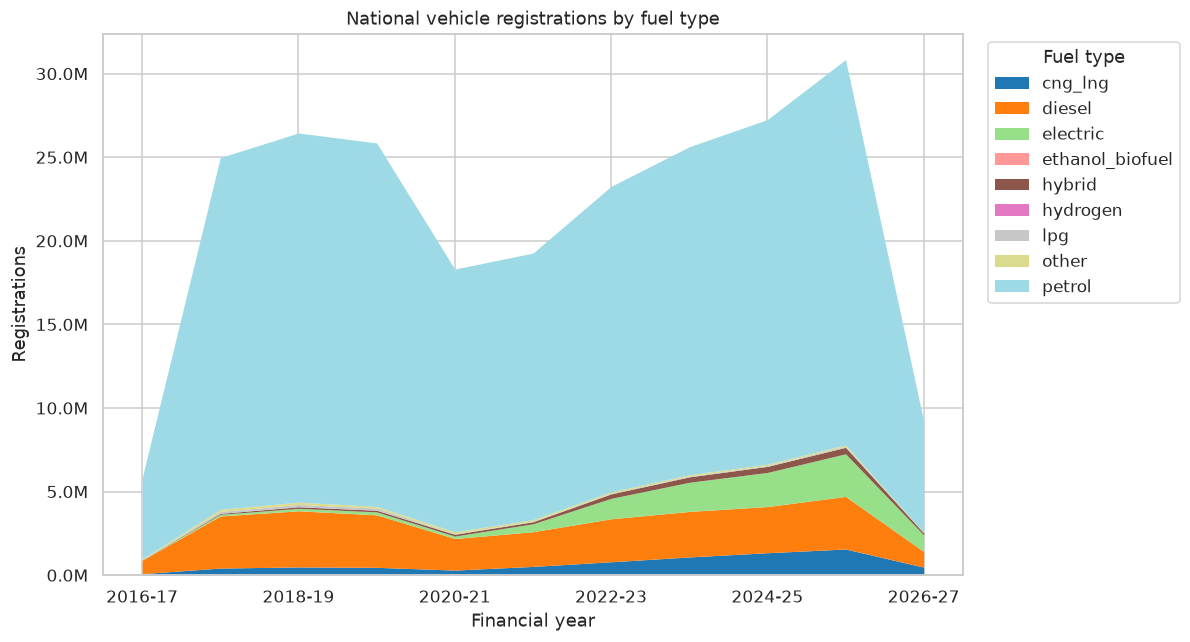

In [3]:
query_fuel_trend = text('''
SELECT financial_year, fuel_type, SUM(registrations) AS registrations
FROM fact_registrations
GROUP BY financial_year, fuel_type
''')

fuel_trend = pd.read_sql(query_fuel_trend, engine)
fuel_trend_pivot = fuel_trend.pivot(index="financial_year", columns="fuel_type", values="registrations").fillna(0)
fuel_trend_pivot = fuel_trend_pivot.sort_index()

fig, ax = plt.subplots(figsize=(11, 6))
fuel_trend_pivot.plot.area(ax=ax, cmap="tab20", linewidth=0)
ax.set_title("National vehicle registrations by fuel type")
ax.set_xlabel("Financial year")
ax.set_ylabel("Registrations")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(title="Fuel type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2. National EV share trend

The core adoption metric this whole project is built around.

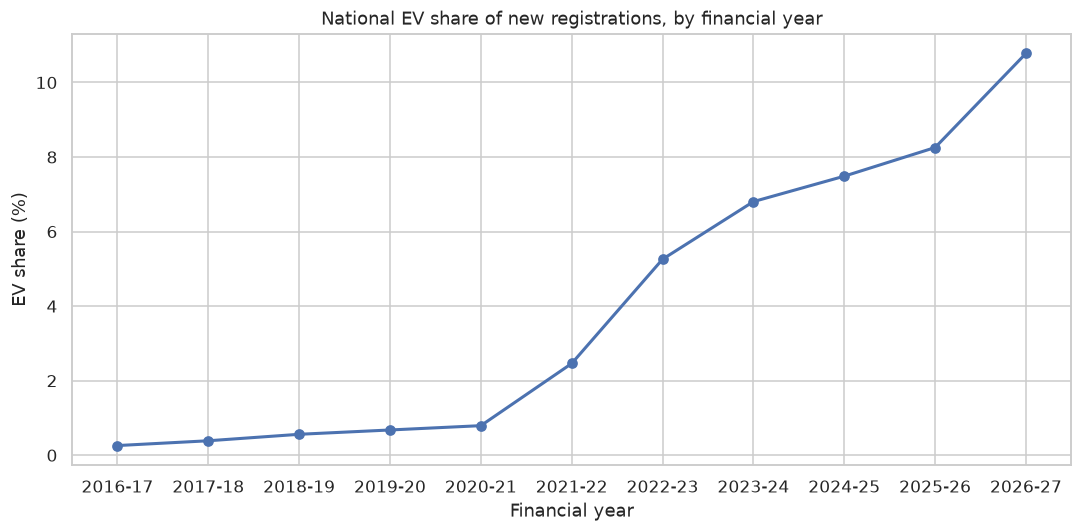

,financial_year,ev_registrations,total_registrations,ev_share_pct
3,2016-17,14980,5802555,0.258162
4,2017-18,96576,24980022,0.386613
10,2018-19,148193,26449617,0.560284
6,2019-20,174792,25854370,0.676064
8,2020-21,145010,18309852,0.791978
9,2021-22,473932,19263984,2.460197
0,2022-23,1222564,23255462,5.257105
2,2023-24,1743008,25622148,6.802740
5,2024-25,2039931,27253238,7.485096
1,2025-26,2545617,30840827,8.254049


In [4]:
query_ev_share = text('''
SELECT financial_year,
       SUM(CASE WHEN fuel_type = 'electric' THEN registrations ELSE 0 END) AS ev_registrations,
       SUM(registrations) AS total_registrations
FROM fact_registrations
GROUP BY financial_year
''')

ev_share = pd.read_sql(query_ev_share, engine).sort_values("financial_year")
ev_share["ev_share_pct"] = 100 * ev_share["ev_registrations"] / ev_share["total_registrations"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ev_share["financial_year"], ev_share["ev_share_pct"], marker="o", linewidth=2)
ax.set_title("National EV share of new registrations, by financial year")
ax.set_xlabel("Financial year")
ax.set_ylabel("EV share (%)")
plt.tight_layout()
plt.show()

ev_share

## 3. State leaderboard — EV share (latest financial year)

Absolute counts favor big states by default; this looks at *share of that
state's own registrations*, which is the fairer adoption-leadership metric.

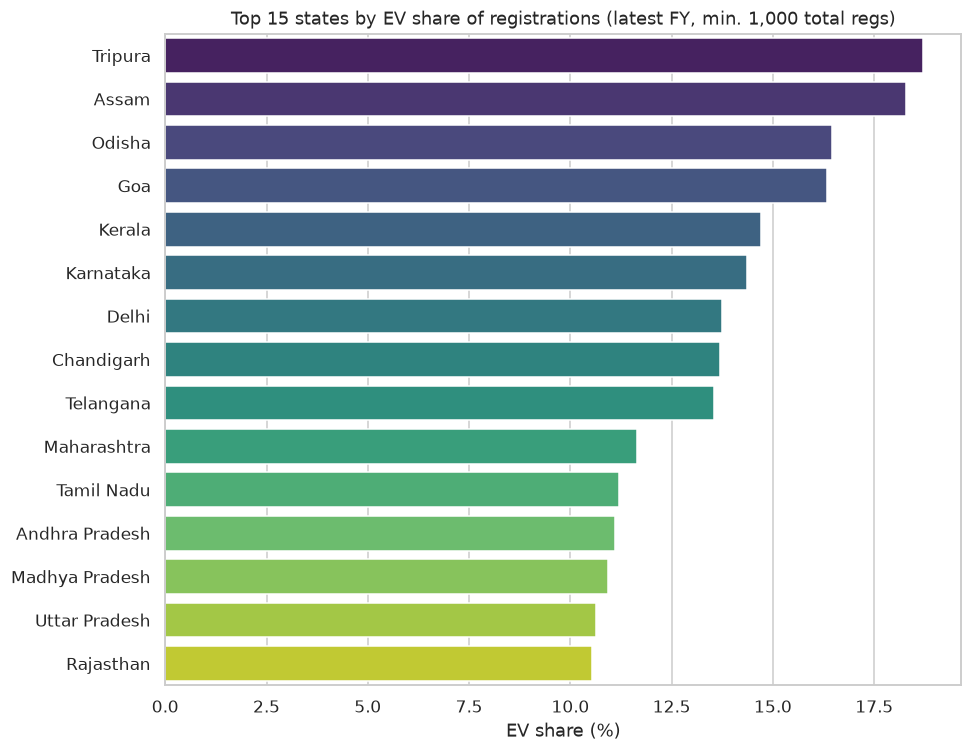

In [5]:
query_state_ev_share = text('''
SELECT s.state_name,
       SUM(CASE WHEN r.fuel_type = 'electric' THEN r.registrations ELSE 0 END) AS ev_registrations,
       SUM(r.registrations) AS total_registrations
FROM fact_registrations r
JOIN dim_state s ON s.state_id = r.state_id
WHERE r.financial_year = (SELECT MAX(financial_year) FROM fact_registrations)
GROUP BY s.state_name
HAVING SUM(r.registrations) > 1000
''')

state_ev_share = pd.read_sql(query_state_ev_share, engine)
state_ev_share["ev_share_pct"] = 100 * state_ev_share["ev_registrations"] / state_ev_share["total_registrations"]
state_ev_share = state_ev_share.sort_values("ev_share_pct", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=state_ev_share, y="state_name", x="ev_share_pct", hue="state_name", legend=False, palette="viridis", ax=ax)
ax.set_title("Top 15 states by EV share of registrations (latest FY, min. 1,000 total regs)")
ax.set_xlabel("EV share (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. EV registrations per 1,000 people, by state

Normalizes for population, correcting the "big state wins by default" bias
in raw counts.

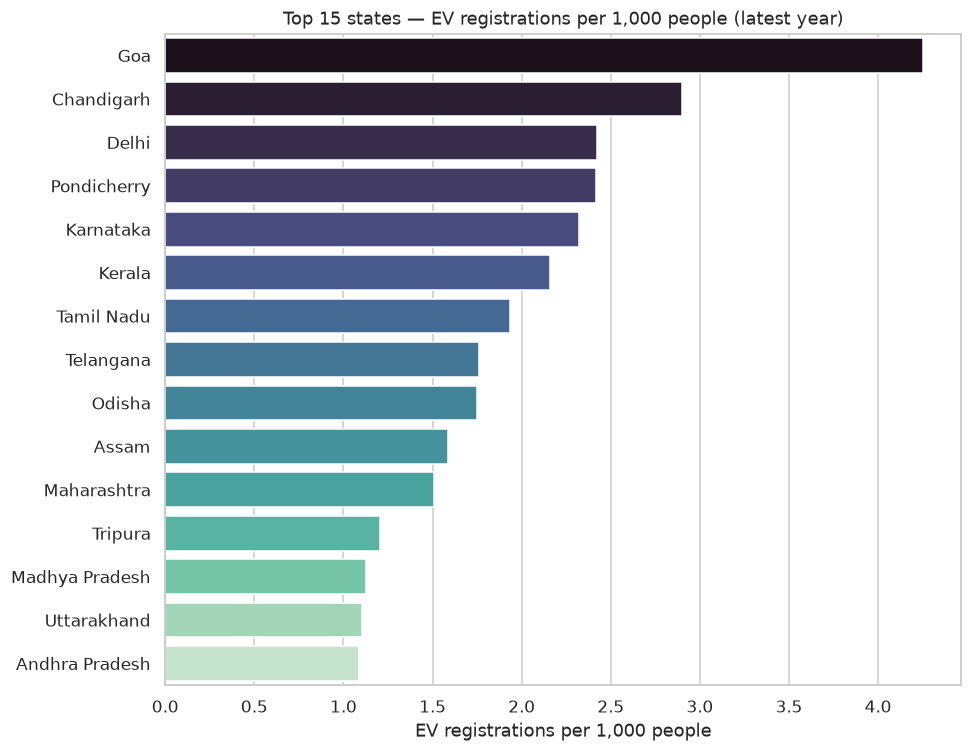

In [6]:
query_ev_per_capita = text('''
SELECT s.state_name, p.year,
       SUM(CASE WHEN r.fuel_type = 'electric' THEN r.registrations ELSE 0 END) AS ev_registrations,
       p.population
FROM fact_registrations r
JOIN dim_state s ON s.state_id = r.state_id
JOIN fact_population p ON p.state_id = r.state_id AND p.year = r.year
WHERE p.year = (SELECT MAX(year) FROM fact_population)
GROUP BY s.state_name, p.year, p.population
''')

ev_per_capita = pd.read_sql(query_ev_per_capita, engine)
ev_per_capita["ev_per_1000"] = 1000 * ev_per_capita["ev_registrations"] / ev_per_capita["population"]
ev_per_capita = ev_per_capita.sort_values("ev_per_1000", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=ev_per_capita, y="state_name", x="ev_per_1000", hue="state_name", legend=False, palette="mako", ax=ax)
ax.set_title("Top 15 states — EV registrations per 1,000 people (latest year)")
ax.set_xlabel("EV registrations per 1,000 people")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Vehicle category mix, over time

Is the composition of India's registered fleet shifting structurally (e.g.
two-wheeler share eroding as car ownership grows)?

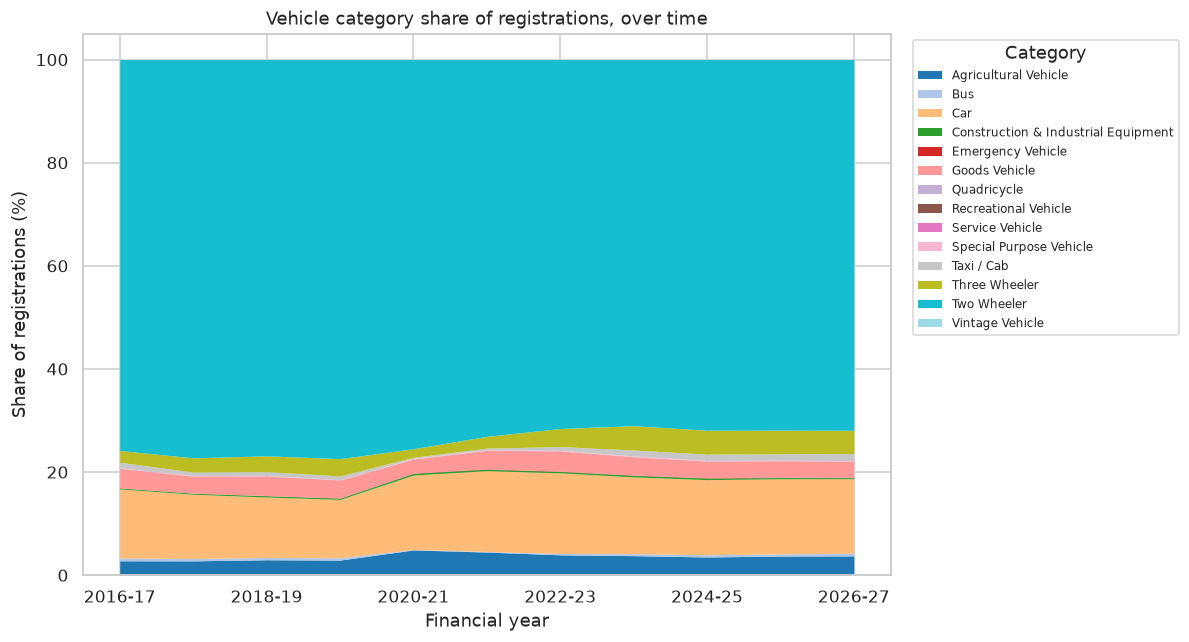

In [7]:
query_category_mix = text('''
SELECT r.financial_year, v.vehicle_category, SUM(r.registrations) AS registrations
FROM fact_registrations r
JOIN dim_vehicle_class v ON v.vehicle_class = r.vehicle_class
GROUP BY r.financial_year, v.vehicle_category
''')

category_mix = pd.read_sql(query_category_mix, engine)
category_pivot = category_mix.pivot(index="financial_year", columns="vehicle_category", values="registrations").fillna(0)
category_pivot = category_pivot.sort_index()
category_share = category_pivot.div(category_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
category_share.plot.area(ax=ax, cmap="tab20", linewidth=0)
ax.set_title("Vehicle category share of registrations, over time")
ax.set_xlabel("Financial year")
ax.set_ylabel("Share of registrations (%)")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Seasonality — registrations by month and year

India's auto market has known seasonal patterns (festival season, financial
year-end). This checks whether that shows up in the data.

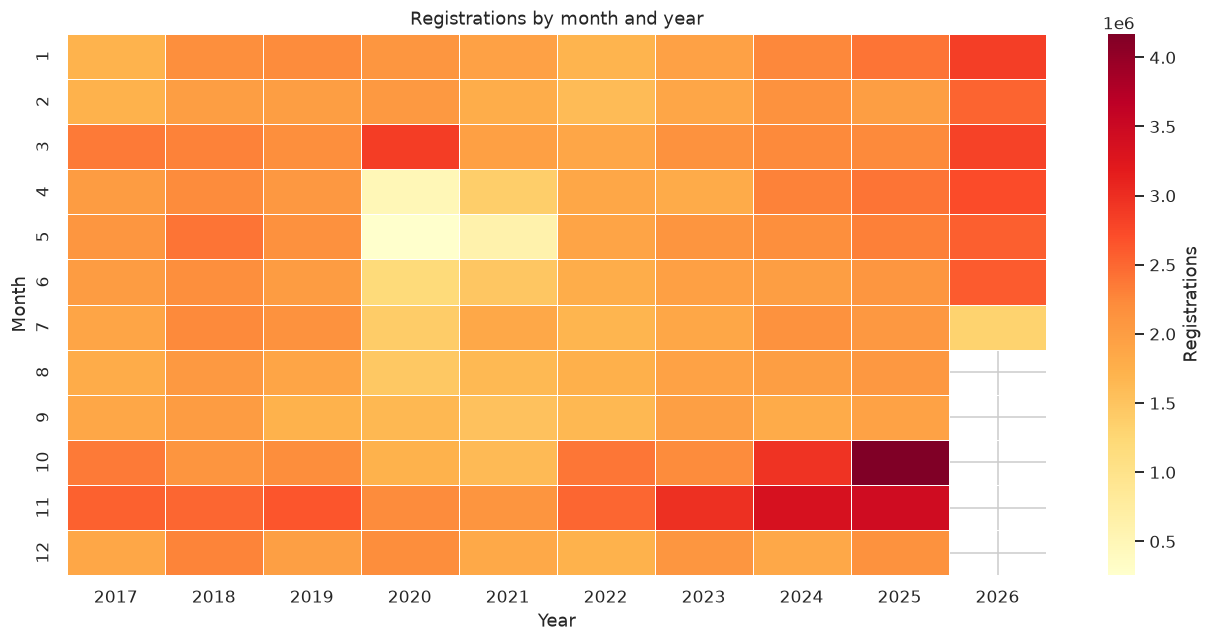

In [8]:
query_seasonality = text('''
SELECT year, month_number, SUM(registrations) AS registrations
FROM fact_registrations
GROUP BY year, month_number
''')

seasonality = pd.read_sql(query_seasonality, engine)
seasonality_pivot = seasonality.pivot(index="month_number", columns="year", values="registrations")

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(seasonality_pivot, cmap="YlOrRd", linewidths=0.5, ax=ax, cbar_kws={"label": "Registrations"})
ax.set_title("Registrations by month and year")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
plt.tight_layout()
plt.show()

## 7. Charging station density vs. cumulative EV share

`fact_charging_stations` is a single snapshot (16-Dec-2025), so this is
necessarily a cross-sectional comparison — one point per state — against
EV share across all years in the fact table, not a year-matched time series.
**Correlation only, not causation**: infrastructure and adoption likely
reinforce each other in both directions.

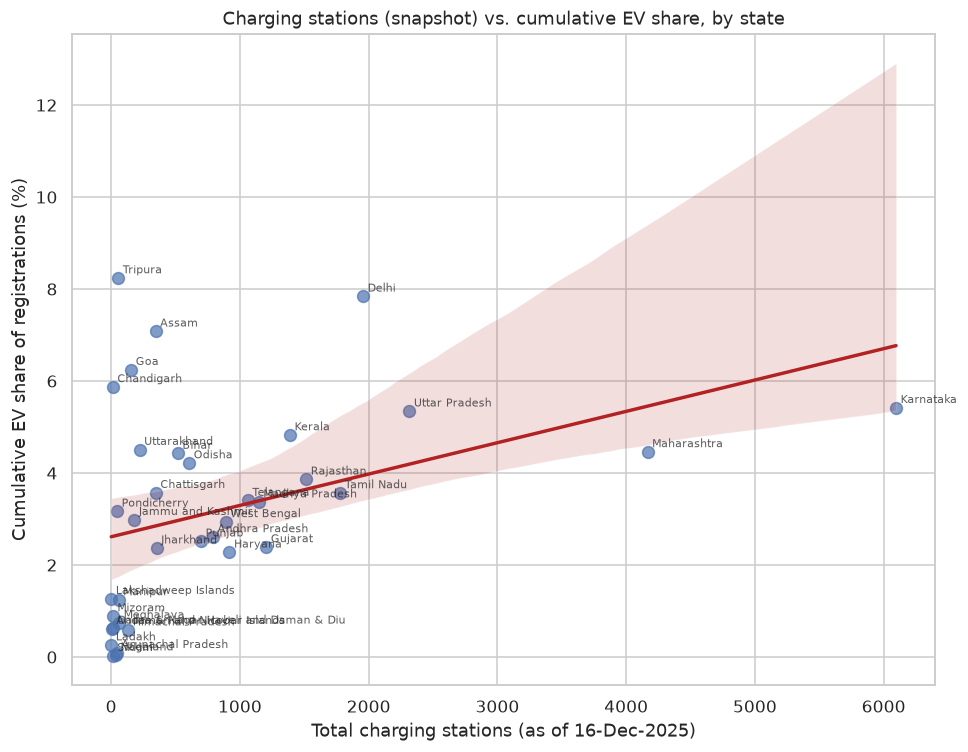

Correlation (charging stations vs EV share): 0.38


In [9]:
query_charging_vs_ev = text('''
SELECT s.state_name, c.total_chargers,
       CAST(SUM(CASE WHEN r.fuel_type = 'electric' THEN r.registrations ELSE 0 END) AS FLOAT)
         / NULLIF(SUM(r.registrations), 0) AS ev_share_to_date
FROM fact_registrations r
JOIN dim_state s ON s.state_id = r.state_id
JOIN fact_charging_stations c ON c.state_id = r.state_id
GROUP BY s.state_name, c.total_chargers
''')

charging_vs_ev = pd.read_sql(query_charging_vs_ev, engine)
charging_vs_ev["ev_share_to_date"] *= 100

fig, ax = plt.subplots(figsize=(9, 7))
sns.regplot(data=charging_vs_ev, x="total_chargers", y="ev_share_to_date", ax=ax,
            scatter_kws={"s": 60, "alpha": 0.7}, line_kws={"color": "firebrick"})
for _, row in charging_vs_ev.iterrows():
    ax.annotate(row["state_name"], (row["total_chargers"], row["ev_share_to_date"]),
                fontsize=7, alpha=0.75, xytext=(3, 3), textcoords="offset points")
ax.set_title("Charging stations (snapshot) vs. cumulative EV share, by state")
ax.set_xlabel("Total charging stations (as of 16-Dec-2025)")
ax.set_ylabel("Cumulative EV share of registrations (%)")
plt.tight_layout()
plt.show()

corr = charging_vs_ev[["total_chargers", "ev_share_to_date"]].corr().iloc[0, 1]
print(f"Correlation (charging stations vs EV share): {corr:.2f}")

## 8. Policy overlay — did EV adoption inflect after a state's policy?

Illustrative before/after view, not a controlled experiment: one time
series per state with its own policy date(s) marked. Worth eyeballing
whether the slope visibly changes after the marked date, but resist reading
too much into a single pre/post comparison per state.

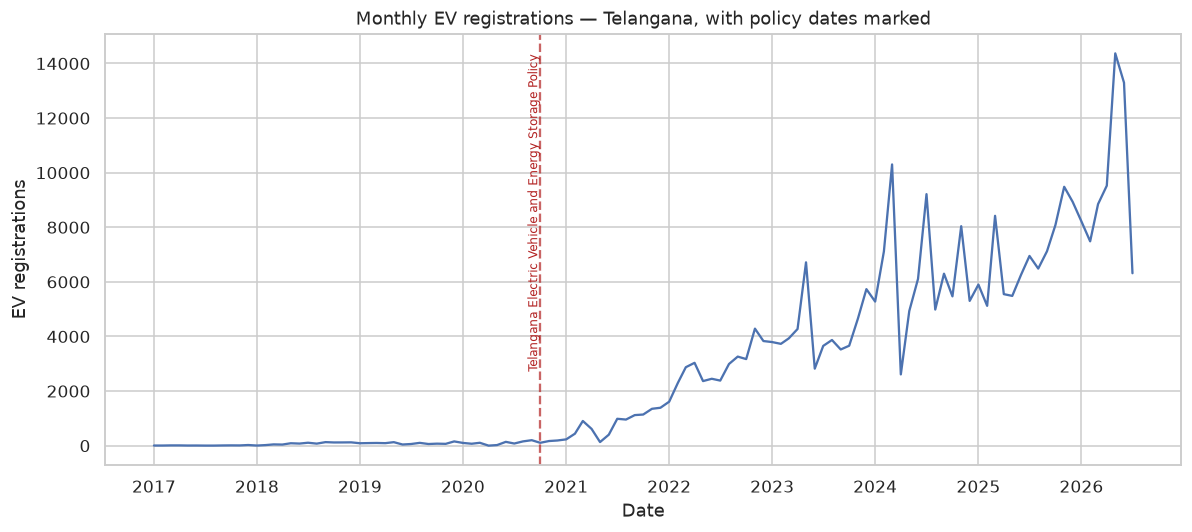

In [12]:
def plot_state_with_policy_overlay(state_name: str):
    query_state_ts = text('''
        SELECT r.year, r.month_number,
               SUM(CASE WHEN r.fuel_type = 'electric' THEN r.registrations ELSE 0 END) AS ev_registrations
        FROM fact_registrations r
        JOIN dim_state s ON s.state_id = r.state_id
        WHERE s.state_name = :state_name
        GROUP BY r.year, r.month_number
    ''')
    ts = pd.read_sql(query_state_ts, engine, params={"state_name": state_name})
    ts["date"] = pd.to_datetime(dict(year=ts.year, month=ts.month_number, day=1))
    ts = ts.sort_values("date")

    query_policies = text('''
        SELECT p.policy_name, p.effective_date
        FROM policy_events p
        JOIN dim_state s ON s.state_id = p.state_id
        WHERE s.state_name = :state_name AND p.effective_date IS NOT NULL
    ''')
    policies = pd.read_sql(query_policies, engine, params={"state_name": state_name})

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(ts["date"], ts["ev_registrations"], linewidth=1.5)
    for _, row in policies.iterrows():
        ax.axvline(row["effective_date"], color="firebrick", linestyle="--", alpha=0.7)
        ax.text(row["effective_date"], ax.get_ylim()[1] * 0.95, row["policy_name"],
                rotation=90, fontsize=8, va="top", ha="right", color="firebrick")
    ax.set_title(f"Monthly EV registrations — {state_name}, with policy dates marked")
    ax.set_xlabel("Date")
    ax.set_ylabel("EV registrations")
    plt.tight_layout()
    plt.show()

plot_state_with_policy_overlay("Telangana")

In [ ]:
plot_state_with_policy_overlay("Kerala")

## 9. Illustrative short-horizon forecast — national EV share

A 12-month Holt-Winters (exponential smoothing) extrapolation of the
national EV-share trend. Framed deliberately as **illustrative**, not a
precise prediction: technology adoption curves are rarely linear, this
model doesn't know about policy changes or supply constraints, and a
longer horizon would compound that uncertainty further. Good for a
"where is this headed if current trend holds" chart, not for anyone's
business plan.

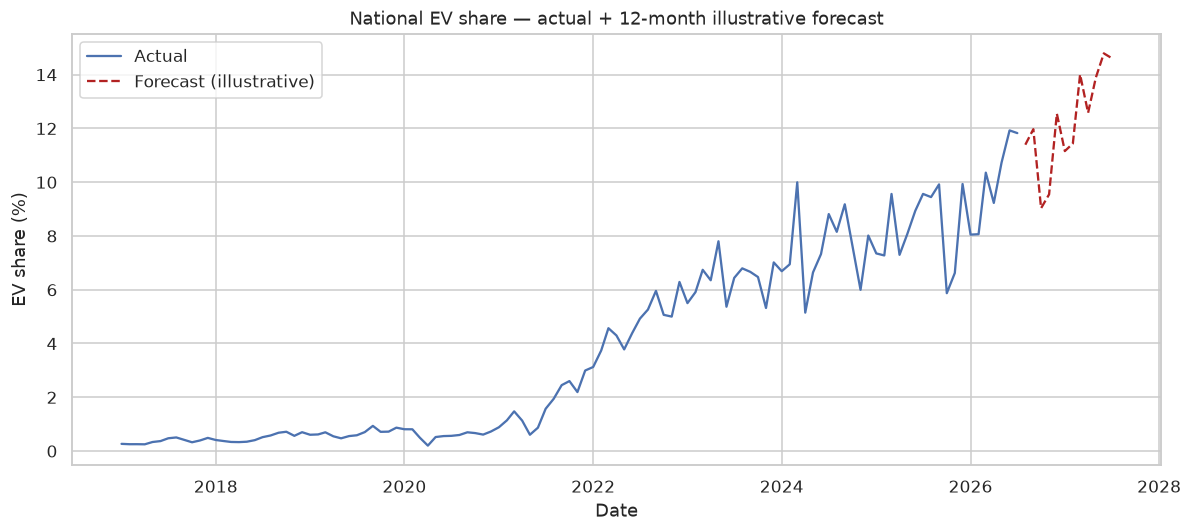

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

query_monthly_ev_share = text('''
SELECT year, month_number,
       CAST(SUM(CASE WHEN fuel_type = 'electric' THEN registrations ELSE 0 END) AS FLOAT)
         / NULLIF(SUM(registrations), 0) AS ev_share
FROM fact_registrations
GROUP BY year, month_number
''')

monthly = pd.read_sql(query_monthly_ev_share, engine)
monthly["date"] = pd.to_datetime(dict(year=monthly.year, month=monthly.month_number, day=1))
monthly = monthly.sort_values("date").set_index("date")["ev_share"] * 100
monthly = monthly.asfreq("MS")

model = ExponentialSmoothing(monthly, trend="add", seasonal="add", seasonal_periods=12).fit()
forecast = model.forecast(12)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, label="Actual")
ax.plot(forecast.index, forecast.values, label="Forecast (illustrative)", linestyle="--", color="firebrick")
ax.set_title("National EV share — actual + 12-month illustrative forecast")
ax.set_xlabel("Date")
ax.set_ylabel("EV share (%)")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

Fill this in once you've actually run the cells and seen your real numbers
— resist the urge to write conclusions before looking at the output. A
few prompts to guide what's worth writing up:

- Which states are genuinely leading EV adoption on a per-capita basis, not
  just in absolute terms?
- Does the vehicle category mix chart show a structural shift, or mostly
  noise?
- Did the Karnataka/Kerala policy overlays show a visible inflection, or
  was adoption already trending that way beforehand?
- Is the charging-station correlation strong enough to lead with, or is it
  a weak, caveat-heavy finding better mentioned briefly?

Next step: pick 4–6 of the strongest charts from above for the Streamlit
dashboard, and write the 3–5 bullet insights for the README described in
the original project roadmap.